# <center>Linear regression II: asymptotics and robust inference</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Replace the finite-sample Gaussian assumptions of Lecture 3 with a set of asymptotic conditions that hold for typical i.i.d. data.

* Prove consistency and asymptotic normality of OLS using the LLN, CLT, CMT, and Slutsky toolkit assembled in Lectures 1–2.

* Derive the Eicker–White heteroskedasticity-robust ("sandwich") variance estimator and its leverage-corrected variants HC1–HC3; verify by Monte Carlo that classical OLS standard errors under-cover when errors are heteroskedastic, while robust standard errors cover correctly.

* Extend the sandwich to **cluster-robust** (CR1 / Liang–Zeger) standard errors for errors correlated within groups, and see in the Moulton experiment how badly classical and HC standard errors fail when both the regressor and the errors are clustered.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapter 7.

**[W]** White, H. (1980). 'A Heteroskedasticity-Consistent Covariance Matrix Estimator and a Direct Test for Heteroskedasticity'. *Econometrica*, 48(4), 817–838.

**[MW]** MacKinnon, J. G., and White, H. (1985). 'Some Heteroskedasticity-Consistent Covariance Matrix Estimators with Improved Finite Sample Properties'. *Journal of Econometrics*, 29(3), 305–325.

**[LZ]** Liang, K.-Y., and Zeger, S. L. (1986). 'Longitudinal Data Analysis Using Generalized Linear Models'. *Biometrika*, 73(1), 13–22.

**[Mou]** Moulton, B. R. (1990). 'An Illustration of a Pitfall in Estimating the Effects of Aggregate Variables on Micro Units'. *Review of Economics and Statistics*, 72(2), 334–338.

**[CGM11]** Cameron, A. C., Gelbach, J. B., and Miller, D. L. (2011). 'Robust Inference With Multiway Clustering'. *Journal of Business & Economic Statistics*, 29(2), 238–249.

# Motivation: from exact to asymptotic inference

* Lecture 3 derived the *exact* finite-sample distribution of OLS under the strong assumption that the errors are i.i.d. Gaussian with constant variance $\sigma^2$. Both halves of that assumption are usually wrong.

* In economic data, error variances typically depend on covariates: log-wages of college graduates are not as variable as log-wages of high-school dropouts; firm-level productivity shocks scale with firm size, and so on. Maintaining homoskedasticity in such settings produces standard errors that systematically misstate the true sampling variability of $\hat\beta$.


* The asymptotic theory developed in this lecture replaces these finite-sample assumptions with weaker conditions and yields inference procedures that remain valid under heteroskedasticity (HC0–HC3). The price is that we trade exactness for $I$-dependence, but recover the same Gaussian critical values asymptotically.

* Heteroskedasticity is not the only failure mode: when errors are *correlated within groups*, students in a school, repeated observations on the same person, even the heteroskedasticity-robust standard errors fail, and inference must be **clustered** at the group level.

## Loading our libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
import statsmodels.api as sm

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


## Loading our data

We continue with the Mroz (1987) Mincer setup of Lecture 3: $I=428$ working women, log-wage as outcome, and a regressor matrix $X$ collecting an intercept, education, experience, and experience squared. (Offline alternative: `pip install wooldridge` then `wooldridge.data('mroz')`.)

In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
mroz_w = mroz.loc[mroz['lfp'] == 1].copy()
mroz_w['lwage'] = np.log(mroz_w['wage'])

y_i = mroz_w['lwage'].values
X_i_k = np.column_stack([
    np.ones(len(mroz_w)),
    mroz_w['educ'].values,
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
var_names = ['intercept', 'educ', 'exper', 'exper^2']
I, K = X_i_k.shape
print(f'I = {I}, K = {K}')


I = 428, K = 4


# 1. Consistency of OLS

## 1.1 Asymptotic assumptions

We replace the finite-sample assumptions of Lecture 3 with conditions that allow us to invoke the LLN and CLT.

**(A1′)** $\{(y_i, x_i)\}_{i\in[I]}$ is i.i.d.<br>
**(A2′)** $\mathbb{E}[x_i x_i^\top] =: Q$ is finite and positive definite.<br>
**(A3′)** $\mathbb{E}[x_i\,\varepsilon_i] = 0$, where $\varepsilon_i := y_i - x_i^\top\beta$.<br>
**(A4′)** $\mathbb{E}\lVert x_i\rVert^4 < \infty$ and $\mathbb{E}[\varepsilon_i^2\lVert x_i\rVert^2] < \infty$.

(A3′) is much weaker than the finite-sample (A2): we no longer require the conditional mean of $\varepsilon$ given $X$ to be zero, only the *unconditional* orthogonality. (A4′) is a standard moment condition that ensures the CLT applies to $x_i\varepsilon_i$. Importantly, we do **not** assume homoskedasticity or any distributional shape for $\varepsilon_i$.

## 1.2 Statement and proof

---

**Theorem (Consistency of OLS).** Under (A1′)–(A4′), $\hat\beta\xrightarrow{p}\beta$.

---

**Proof.** Decompose
$$
\hat\beta - \beta = \bigl(I^{-1}X^\top X\bigr)^{-1}\bigl(I^{-1}X^\top\varepsilon\bigr) = \widehat Q_I^{-1}\,\widehat g_I,
$$
where $\widehat Q_I := I^{-1}\sum_i x_i x_i^\top$ and $\widehat g_I := I^{-1}\sum_i x_i\varepsilon_i$.

By the Khintchine LLN applied componentwise, $\widehat Q_I\xrightarrow{p}Q$ and $\widehat g_I\xrightarrow{p}\mathbb{E}[x_i\varepsilon_i] = 0$: the first under the moment condition $\mathbb{E}\lVert x_i\rVert^2 < \infty$ from (A4′), the second under (A3′) and (A4′). The map $(A,b)\mapsto A^{-1}b$ is continuous at $(Q,0)$ since $Q$ is invertible by (A2′), so by the Continuous Mapping Theorem $\hat\beta - \beta\xrightarrow{p} Q^{-1}\cdot 0 = 0$. $\square$

## 1.3 Numerical demonstration

We simulate i.i.d. data $(y_i, x_i)$ from a heteroskedastic linear model and show that $\hat\beta$ converges to the true $\beta$ as $I$ grows. The design borrows $X$ from Mroz (resampled with replacement to grow $I$); the errors are heteroskedastic with $\sigma_i^2 = \exp(\alpha_0 + \alpha_1\,\text{educ}_i)$, mimicking the empirical fact that log-wage variance increases with education.

> **What $\beta$ means under (A3$'$).** With only unconditional orthogonality, $\beta$ is the coefficient of the **population linear projection** of $y$ on $x$. It need not be a structural or causal parameter, and $\mathbb{E}[\varepsilon\mid x]$ may well be nonzero. Robust standard errors repair heteroskedasticity; they do *not* repair a failure of the orthogonality condition.

In [3]:
def simulate_heteroskedastic(I_sim, Xpop_i_k, βtrue_k, α0=-2.0, α1=0.3, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    idraw_i = rng.integers(0, Xpop_i_k.shape[0], size=I_sim)
    Xsim_i_k = Xpop_i_k[idraw_i]
    educ_i = Xsim_i_k[:, 1]
    σ_i = np.sqrt(np.exp(α0 + α1 * educ_i))
    εsim_i = σ_i * rng.standard_normal(I_sim)
    ysim_i = Xsim_i_k @ βtrue_k + εsim_i
    return Xsim_i_k, ysim_i

def ols(X_i_k, y_i):
    XtX_k_k = X_i_k.T @ X_i_k
    Xty_k   = X_i_k.T @ y_i
    β_k    = np.linalg.solve(XtX_k_k, Xty_k)
    yhat_i = X_i_k @ β_k
    εhat_i = y_i - yhat_i
    return SimpleNamespace(β_k=β_k, yhat_i=yhat_i, εhat_i=εhat_i,
                           I=X_i_k.shape[0], K=X_i_k.shape[1],
                           XtXinv_k_k=np.linalg.inv(XtX_k_k))

# Truth: the sample estimate from Mroz, taken as if it were the population value
βtrue_k = ols(X_i_k, y_i).β_k.copy()

rng_mc = np.random.default_rng(2026)
I_s = [50, 200, 1_000, 10_000, 100_000]      # grid of sample sizes, s in [S]
R = 200

records = []
for I_sim in I_s:
    β_r_k = np.empty((R, K))
    for r in range(R):
        Xsim_i_k, ysim_i = simulate_heteroskedastic(I_sim, X_i_k, βtrue_k, rng=rng_mc)
        β_r_k[r] = ols(Xsim_i_k, ysim_i).β_k
    records.append((I_sim, β_r_k.mean(axis=0), β_r_k.std(axis=0)))

print(f"{'I':>8s}" + ''.join(f'{name:>14s}' for name in var_names))
print(f"{'truth':>8s}" + ''.join(f'{βtrue_k[k]:>14.5f}' for k in range(K)))
for I_sim, mean_k, sd_k in records:
    print(f'{I_sim:>8d}' + ''.join(f'{mean_k[k]:>10.5f}±{sd_k[k]:.3f}' for k in range(K)))


       I     intercept          educ         exper       exper^2
   truth      -0.52204       0.10749       0.04157      -0.00081
      50  -0.66982±2.943   0.12225±0.238   0.03044±0.179  -0.00038±0.006
     200  -0.58147±1.377   0.11115±0.106   0.04681±0.076  -0.00096±0.002
    1000  -0.55080±0.589   0.11011±0.048   0.03941±0.033  -0.00070±0.001
   10000  -0.54138±0.186   0.10831±0.015   0.04331±0.010  -0.00086±0.000
  100000  -0.52443±0.059   0.10761±0.005   0.04167±0.003  -0.00081±0.000


Each row is the across-replication mean of $\hat\beta$ at sample size $I$, with the across-replication standard deviation as a "$\pm$" tag. As $I$ grows, the means converge to the true $\beta$ and the standard deviations shrink at the expected $I^{-1/2}$ rate. Consistency made flesh.

# 2. Asymptotic normality of OLS

## 2.1 Statement

---

**Theorem (Asymptotic normality).** Under (A1′)–(A4′),
$$
\sqrt{I}\,(\hat\beta - \beta)\;\xrightarrow{d}\;\mathcal{N}\bigl(0,\;V\bigr), \qquad V := Q^{-1}\,\Omega\,Q^{-1},
$$
where $Q := \mathbb{E}[x_i x_i^\top]$ and $\Omega := \mathbb{E}[\varepsilon_i^2\,x_i x_i^\top]$.

---

**Proof.** Continuing from §1.2,
$$
\sqrt{I}\,(\hat\beta - \beta) = \widehat Q_I^{-1}\cdot \sqrt{I}\,\widehat g_I
= \widehat Q_I^{-1}\cdot \frac{1}{\sqrt I}\sum_{i\in[I]} x_i\varepsilon_i.
$$
The summands $x_i\varepsilon_i$ are i.i.d. with mean zero (by (A3′)) and finite covariance $\Omega$ (by (A4′)). By the Lindeberg–Lévy CLT,
$$
\frac{1}{\sqrt I}\sum_i x_i\varepsilon_i\;\xrightarrow{d}\;\mathcal{N}(0,\Omega).
$$
Combined with $\widehat Q_I\xrightarrow{p}Q$ (LLN) and the continuity of matrix inversion at $Q$ (CMT), Slutsky's theorem yields the claim. $\square$

## 2.2 The sandwich form and its homoskedastic special case

The asymptotic variance $V = Q^{-1}\Omega\,Q^{-1}$ is the celebrated *sandwich form*: the "bread" $Q^{-1}$ comes from inverting the design moment matrix and the "filling" $\Omega$ summarizes the second moment of the score $x_i\varepsilon_i$.

Under the additional assumption of conditional homoskedasticity, $\mathbb{E}[\varepsilon_i^2\mid x_i] = \sigma^2$, the filling factorizes:
$$
\Omega = \mathbb{E}[\varepsilon_i^2\,x_i x_i^\top] = \mathbb{E}\bigl[\mathbb{E}[\varepsilon_i^2\mid x_i]\,x_i x_i^\top\bigr] = \sigma^2\,Q,
$$
and the sandwich collapses to
$$
V = \sigma^2\,Q^{-1}.
$$
The classical OLS variance estimator $\widehat V_{\text{cl}} = \hat\sigma^2(X^\top X/I)^{-1}$ is the sample analog of this special case, which is why it is *consistent only under homoskedasticity*. When errors are heteroskedastic, the classical estimator targets the wrong asymptotic object.

# 3. Heteroskedasticity-robust standard errors

## 3.1 The Eicker–White estimator (HC0)

The natural sample analog of $V = Q^{-1}\Omega Q^{-1}$ is
$$
\widehat V^{HC0} := \widehat Q_I^{-1}\,\widehat\Omega_I\,\widehat Q_I^{-1}, \qquad \widehat\Omega_I := \frac{1}{I}\sum_{i\in[I]} \hat\varepsilon_i^2\,x_i x_i^\top,
$$
which uses the squared OLS residuals $\hat\varepsilon_i^2$ in place of the unknown $\varepsilon_i^2$. We should distinguish what is being estimated consistently here, because the natural reading is the wrong one: $\hat\varepsilon_i^2$ is **not** a consistent estimator of $\mathbb{E}[\varepsilon_i^2\mid x_i]$ at the point $x_i$, it is a single squared draw, and its own variance does not shrink as $I$ grows. What converges is the *average* $\widehat\Omega_I \xrightarrow{p} \mathbb{E}[\varepsilon_i^2 x_i x_i^\top]$: the individual errors are noisy but they average out across observations, which is all the sandwich formula needs. White (1980) showed that $\widehat V^{HC0}\xrightarrow{p} V$ under (A1′)–(A4′), with no homoskedasticity assumption. The acronym **HC** stands for *heteroskedasticity-consistent*: the estimator remains consistent for $V$ whether or not the error variance is constant. The index **0** marks it as the baseline of the family HC0–HC3 [MW]: the raw plug-in version, with no finite-sample correction, its leverage-corrected refinements are numbered 1 to 3 in §3.2.

The corresponding finite-sample estimator of $\operatorname{Var}(\hat\beta)$ is
$$
\widehat{\operatorname{Var}}(\hat\beta)^{HC0} = \widehat V^{HC0}/I = (X^\top X)^{-1}\,\bigl(\textstyle\sum_i \hat\varepsilon_i^2\,x_i x_i^\top\bigr)\,(X^\top X)^{-1}.
$$

## 3.2 Leverage-corrected variants HC1–HC3

HC0 tends to be downward-biased in finite samples because the OLS residuals $\hat\varepsilon$ systematically underestimate $\varepsilon$ (residuals are projections of $\varepsilon$ onto the orthogonal complement of $X$, hence shorter). MacKinnon and White (1985) proposed three small-sample corrections built on the leverage values $h_i := x_i^\top(X^\top X)^{-1}x_i$, which lie in $[0,1]$ and average to $K/I$:

$$
\begin{aligned}
\widehat{\operatorname{Var}}^{HC1} &= \frac{I}{I-K}\,\widehat{\operatorname{Var}}^{HC0}, \\
\widehat{\operatorname{Var}}^{HC2} &= (X^\top X)^{-1}\,\bigl(\textstyle\sum_i\frac{\hat\varepsilon_i^2}{1-h_i}\,x_i x_i^\top\bigr)\,(X^\top X)^{-1}, \\
\widehat{\operatorname{Var}}^{HC3} &= (X^\top X)^{-1}\,\bigl(\textstyle\sum_i\frac{\hat\varepsilon_i^2}{(1-h_i)^2}\,x_i x_i^\top\bigr)\,(X^\top X)^{-1}.
\end{aligned}
$$

Stata's default and the most widely cited in applied work is HC1; HC2 and HC3 are less biased but slightly less standard. We implement all four.

## 3.3 DIY implementation

In [4]:
def vcov_robust(X_i_k, εhat_i, hc='HC0'):
    I, K = X_i_k.shape
    XtXinv_k_k = np.linalg.inv(X_i_k.T @ X_i_k)
    if hc == 'HC0':
        e2_i = εhat_i ** 2
    elif hc == 'HC1':
        e2_i = (I / (I - K)) * εhat_i ** 2
    elif hc in ('HC2', 'HC3'):
        # Leverage h_i = x_i' (X'X)^{-1} x_i, vectorized
        h_i = (X_i_k * (XtXinv_k_k @ X_i_k.T).T).sum(axis=1)
        if hc == 'HC2':
            e2_i = εhat_i ** 2 / (1 - h_i)
        else:  # HC3
            e2_i = εhat_i ** 2 / (1 - h_i) ** 2
    else:
        raise ValueError(f'unknown hc={hc!r}')
    Ω_k_k = (X_i_k * e2_i[:, None]).T @ X_i_k
    return XtXinv_k_k @ Ω_k_k @ XtXinv_k_k

# Apply each variant to the Mroz Mincer regression
fit = ols(X_i_k, y_i)
σ2 = (fit.εhat_i @ fit.εhat_i) / (I - K)
Vcl_k_k = σ2 * fit.XtXinv_k_k

print(f"{'name':<12s}{'classical':>12s}" + ''.join(f'{hc:>10s}' for hc in ['HC0', 'HC1', 'HC2', 'HC3']))
for k, name in enumerate(var_names):
    cls = np.sqrt(Vcl_k_k[k, k])
    se_row = [np.sqrt(vcov_robust(X_i_k, fit.εhat_i, hc)[k, k]) for hc in ['HC0', 'HC1', 'HC2', 'HC3']]
    print(f'{name:<12s}{cls:>12.5f}' + ''.join(f'{s:>10.5f}' for s in se_row))


name           classical       HC0       HC1       HC2       HC3
intercept        0.19863   0.20071   0.20165   0.20210   0.20350
educ             0.01415   0.01316   0.01322   0.01325   0.01334
exper            0.01318   0.01520   0.01527   0.01534   0.01548
exper^2          0.00039   0.00042   0.00042   0.00042   0.00043


The four robust SEs differ from the classical SE, and from one another, most visibly on the intercept and `exper^2` coefficients. Since $(1-h_i)^{-2}\ge(1-h_i)^{-1}\ge 1$, HC3 dominates HC2 dominates HC0 termwise; HC3 need *not* exceed HC1 in every design, though the ordering HC0 < HC1 < HC2 < HC3 is what one typically sees in practice (and does hold here).

## 3.4 Sanity check against `statsmodels`

In [5]:
for hc in ['HC0', 'HC1', 'HC2', 'HC3']:
    sm_fit = sm.OLS(y_i, X_i_k).fit(cov_type=hc)
    diy_k = np.sqrt(np.diag(vcov_robust(X_i_k, fit.εhat_i, hc)))
    diff = np.max(np.abs(diy_k - sm_fit.bse))
    print(f'{hc}: max |diy - sm| = {diff:.3e}')


HC0: max |diy - sm| = 2.776e-16
HC1: max |diy - sm| = 1.141e-14
HC2: max |diy - sm| = 6.661e-16
HC3: max |diy - sm| = 1.749e-15


## 3.5 Why robust SEs matter: Monte Carlo coverage

We generate data from the heteroskedastic DGP of §1.3 and compute, for each replication, the 95% confidence interval for $\beta_{\text{educ}}$ using both the classical SE and HC1/HC3. We then count what fraction of intervals cover the true coefficient. With nominally 95% intervals we expect 95% coverage; deviations reveal whether a procedure is well-calibrated.

In [6]:
rng_mc = np.random.default_rng(2026)
R = 2_000
I_sim = 1_000

cover_classical = 0
cover_HC1 = 0
cover_HC3 = 0
α = 0.05
z_crit = stats.norm.ppf(1 - α / 2)

# keep the studentized errors as well, so the coverage numbers can be seen and not just read
tcl_r, tHC1_r, tHC3_r = np.empty(R), np.empty(R), np.empty(R)

for r in range(R):
    Xsim_i_k, ysim_i = simulate_heteroskedastic(I_sim, X_i_k, βtrue_k, rng=rng_mc)
    fs = ols(Xsim_i_k, ysim_i)
    σ2_s = (fs.εhat_i @ fs.εhat_i) / (I_sim - K)
    Vcl_k_k  = σ2_s * fs.XtXinv_k_k
    VHC1_k_k = vcov_robust(Xsim_i_k, fs.εhat_i, 'HC1')
    VHC3_k_k = vcov_robust(Xsim_i_k, fs.εhat_i, 'HC3')

    k_educ = 1
    βh = fs.β_k[k_educ]
    for V_k_k, counter in [(Vcl_k_k, 'cl'), (VHC1_k_k, 'HC1'), (VHC3_k_k, 'HC3')]:
        se = np.sqrt(V_k_k[k_educ, k_educ])
        lo, hi = βh - z_crit * se, βh + z_crit * se
        covers = (lo <= βtrue_k[k_educ] <= hi)
        t_r = (βh - βtrue_k[k_educ]) / se
        if counter == 'cl':
            cover_classical += covers
            tcl_r[r] = t_r
        if counter == 'HC1':
            cover_HC1 += covers
            tHC1_r[r] = t_r
        if counter == 'HC3':
            cover_HC3 += covers
            tHC3_r[r] = t_r

print(f'Coverage of nominally 95% CIs for β_educ across R = {R} replications:')
print(f'  classical SE  : {cover_classical/R:.3f}')
print(f'  HC1           : {cover_HC1/R:.3f}')
print(f'  HC3           : {cover_HC3/R:.3f}')


Coverage of nominally 95% CIs for β_educ across R = 2000 replications:
  classical SE  : 0.887
  HC1           : 0.941
  HC3           : 0.942


The three coverage numbers come from one object: the distribution of the studentized error $(\hat\beta_{educ} - \beta_{educ})/\widehat{se}$. The Wald interval is exactly the statement that this is standard normal. Under heteroskedasticity the classical standard error is too small, so its studentized error is over-dispersed: the tails run past $\pm 1.96$ far more than 5% of the time, and that excess *is* the coverage shortfall.

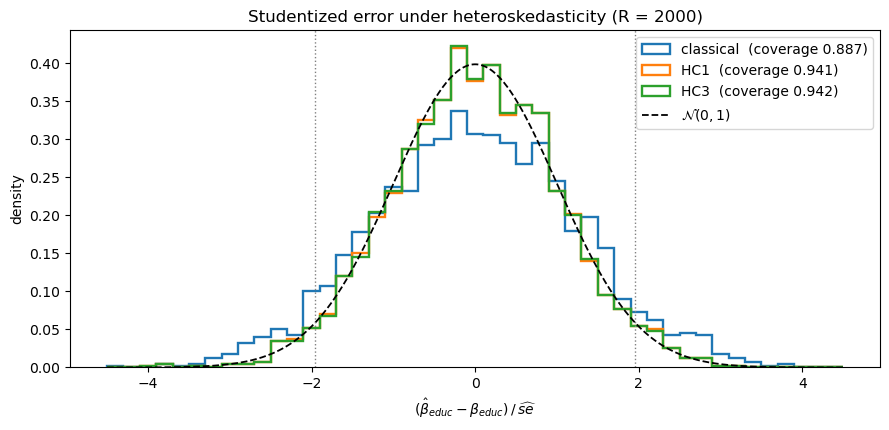

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.4))
grid = np.linspace(-4.5, 4.5, 400)      # fine grid, for the reference density
bins_t = np.linspace(-4.5, 4.5, 46)     # coarse bins, for the histograms
for t_r, lab, cov in [(tcl_r, 'classical', cover_classical / R),
                      (tHC1_r, 'HC1', cover_HC1 / R),
                      (tHC3_r, 'HC3', cover_HC3 / R)]:
    ax.hist(t_r, bins=bins_t, density=True, histtype='step', lw=1.7,
            label=f'{lab}  (coverage {cov:.3f})')
ax.plot(grid, stats.norm.pdf(grid), color='k', ls='--', lw=1.3,
        label=r'$\mathcal{N}(0,1)$')
for z in (-z_crit, z_crit):
    ax.axvline(z, color='0.5', ls=':', lw=1)
ax.set_xlabel(r'$(\hat\beta_{educ} - \beta_{educ})\,/\,\widehat{se}$')
ax.set_ylabel('density')
ax.set_title(f'Studentized error under heteroskedasticity (R = {R})')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


The classical procedure under-covers by about 6 percentage points, its nominal 95% interval covers only $\sim$89% of the time when errors are heteroskedastic, while HC1 and HC3 deliver near-nominal coverage. The gap widens when the heteroskedasticity is stronger and shrinks when it is weaker; what is invariant is that classical SEs have *no* asymptotic justification once homoskedasticity is dropped.

# 4. Cluster-robust standard errors

## 4.1 Setup

Suppose observations come in $G$ clusters indexed by $g$, with cluster sizes $I_g$ and $\sum_g I_g = I$. Within a cluster, the errors $\varepsilon_{i,g}$ may be arbitrarily correlated; across clusters, they are independent. Examples: students within a school, individuals within a household, observations within a time period.

The score $x_i\varepsilon_i$ is no longer i.i.d., but the *cluster sums*
$$
s_g := \sum_{i\in g} x_{i,g}\varepsilon_{i,g}
$$
are **independent across clusters** (they need not be identically distributed when cluster sizes differ). The key move is to normalise by the number of **clusters** rather than observations. With balanced clusters of common size $I_g$ (so $I = I_g\,G$), $G\to\infty$, and a cluster-level LLN and CLT,
$$
\sqrt G\,(\hat\beta-\beta)
= \Bigl(\tfrac1G\sum_g X_g^\top X_g\Bigr)^{-1}\tfrac1{\sqrt G}\sum_g s_g
\;\xrightarrow{d}\;\mathcal{N}\bigl(0,\;Q_C^{-1}\Omega_C Q_C^{-1}\bigr),
\qquad
Q_C := \mathbb{E}[X_g^\top X_g],\quad \Omega_C := \mathbb{E}[s_g s_g^\top].
$$
Both $Q_C$ and $\Omega_C$ are defined **per cluster**, which is what makes them compatible with the $\sqrt G$ scaling: mixing a cluster-level filling with the observation-level bread $\widehat Q_I = I^{-1}X^\top X$ would be off by the average cluster size. The practical reading: it is $G$, not $I$, that is the effective sample size.

## 4.2 The CR1 estimator

The Liang–Zeger (1986) cluster-robust estimator replaces the i.i.d. filling of HC0 with a sum over cluster scores:
$$
\widehat{\operatorname{Var}}(\hat\beta)^{CR1}
= c\,(X^\top X)^{-1}\,\biggl(\sum_{g=1}^G \biggl(\sum_{i\in g}\hat\varepsilon_i\,x_i\biggr)\biggl(\sum_{i\in g}\hat\varepsilon_i\,x_i\biggr)^\top\biggr)\,(X^\top X)^{-1},
$$
where $c = \frac{G}{G-1}\cdot\frac{I-1}{I-K}$ is the standard small-sample correction (Stata's default). Note that CR1 reduces to HC1 when each cluster is a singleton ($I_g=1$ for all $g$).

## 4.3 DIY implementation

In [8]:
def vcov_cluster(X_i_k, εhat_i, cluster_i, small_sample=True):
    I, K = X_i_k.shape
    XtXinv_k_k = np.linalg.inv(X_i_k.T @ X_i_k)
    Ω_k_k = np.zeros((K, K))
    unique_g = np.unique(cluster_i)
    G = len(unique_g)
    for g in unique_g:
        in_g_i = (cluster_i == g)
        sg_k = X_i_k[in_g_i].T @ εhat_i[in_g_i]    # K-vector: cluster score
        Ω_k_k += np.outer(sg_k, sg_k)
    V_k_k = XtXinv_k_k @ Ω_k_k @ XtXinv_k_k
    if small_sample:
        V_k_k *= (G / (G - 1)) * ((I - 1) / (I - K))
    return V_k_k


## 4.4 Numerical demonstration: the Moulton case

We simulate the canonical case studied by Moulton (1990): a regressor that is *constant within cluster* (think: a treatment assigned at the village or class level), combined with cluster-correlated errors. The clusters are 50 groups of $I_g = 20$ observations each; within each cluster, the error has a cluster-level shock that induces an intracluster correlation $\rho\approx 0.5$. This is the setting in which classical SEs can fail severely: when both the regressor and the errors are clustered, ignoring the dependence dramatically understates sampling uncertainty.

In [9]:
def simulate_clustered(G=50, I_g=20, ρ=0.5, βtrue_k=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    if βtrue_k is None:
        βtrue_k = np.array([1.0, 0.5])
    I = G * I_g
    cluster_i = np.repeat(np.arange(G), I_g)

    # Cluster-level regressor: x_i is constant within each cluster.
    # This is the "treatment at cluster level" case (Moulton 1990) where
    # cluster correlation in ε translates into cluster correlation in xε.
    z_g = rng.standard_normal(G)
    x_i = z_g[cluster_i]
    Xsim_i_k = np.column_stack([np.ones(I), x_i])

    # Cluster-correlated errors: ε = α_g + u_i with intracluster corr ρ
    σ_α = np.sqrt(ρ)
    σ_u = np.sqrt(1 - ρ)
    α_g = σ_α * rng.standard_normal(G)
    u_i = σ_u * rng.standard_normal(I)
    εsim_i = α_g[cluster_i] + u_i
    ysim_i = Xsim_i_k @ βtrue_k + εsim_i
    return Xsim_i_k, ysim_i, cluster_i

rng_mc = np.random.default_rng(2026)
R = 2_000
βtruec_k = np.array([1.0, 0.5])
α = 0.05
z_crit = stats.norm.ppf(1 - α / 2)

cover = {'classical': 0, 'HC1': 0, 'CR1': 0}
mean_se = {'classical': 0.0, 'HC1': 0.0, 'CR1': 0.0}

for r in range(R):
    Xsim_i_k, ysim_i, cluster_i = simulate_clustered(G=50, I_g=20, ρ=0.5, βtrue_k=βtruec_k, rng=rng_mc)
    fs = ols(Xsim_i_k, ysim_i)
    I_sim, K_sim = Xsim_i_k.shape
    σ2_s = (fs.εhat_i @ fs.εhat_i) / (I_sim - K_sim)
    Vcl_k_k  = σ2_s * fs.XtXinv_k_k
    VHC1_k_k = vcov_robust(Xsim_i_k, fs.εhat_i, 'HC1')
    VCR1_k_k = vcov_cluster(Xsim_i_k, fs.εhat_i, cluster_i)
    k_slope = 1
    for label, V_k_k in [('classical', Vcl_k_k), ('HC1', VHC1_k_k), ('CR1', VCR1_k_k)]:
        se = np.sqrt(V_k_k[k_slope, k_slope])
        mean_se[label] += se
        lo, hi = fs.β_k[k_slope] - z_crit * se, fs.β_k[k_slope] + z_crit * se
        cover[label] += (lo <= βtruec_k[k_slope] <= hi)

print(f'Cluster-correlated DGP: ρ = 0.5, G = 50, I_g = 20, X constant within cluster, R = {R}')
print(f"{'procedure':<12s}{'mean SE':>10s}{'coverage of 95% CI':>22s}")
for label in ['classical', 'HC1', 'CR1']:
    print(f'{label:<12s}{mean_se[label]/R:>10.4f}{cover[label]/R:>22.3f}')


Cluster-correlated DGP: ρ = 0.5, G = 50, I_g = 20, X constant within cluster, R = 2000
procedure      mean SE    coverage of 95% CI
classical       0.0322                 0.457
HC1             0.0318                 0.457
CR1             0.1010                 0.924


The conclusion is clear. Both classical and HC1 SEs miss the within-cluster correlation entirely and produce CIs that cover the true slope only $\sim$46% of the time, far below the nominal 95%. CR1 recovers near-nominal coverage. The mean SE column shows where the under-coverage comes from: classical and HC1 SEs are roughly *one third* the size they should be; for this balanced, equicorrelated design with the regressor constant within cluster, the inflation factor between them and CR1 is the *Moulton factor* $\sqrt{1 + (I_g - 1)\rho}\approx \sqrt{1 + 19\cdot 0.5}\approx 3.2$.

This failure is common in applied work when observations are clustered: it is the reason "did you cluster the standard errors?" is among the first questions asked in any empirical seminar.

# Looking ahead

The asymptotic machinery assembled here, consistency, asymptotic normality, and the sandwich variance in its heteroskedasticity-robust (HC0–HC3) and cluster-robust (CR1) forms, is the foundation for everything that follows.

* **Lecture 5** takes the second route out of non-spherical errors. Rather than keeping OLS and repairing its variance estimate, *generalized least squares* models the error covariance $\Omega$ and reweights: recovering efficiency (Aitken's theorem) at the price of having to get $\Omega$ right. The random-effects panel estimator and the Prais–Winsten correction for serial correlation both turn out to be instances of it.

* **Lecture 6** turns asymptotic normality of $\hat\beta$ into inference on *nonlinear functions* of it (the **delta method**) and on *joint restrictions* (the **Wald test**).

* Cluster-robust inference returns as the default in the panel-data and difference-in-differences lectures, where observations cluster by individual. And the same sandwich template extends, essentially unchanged, to nonlinear estimators, maximum likelihood (the score in place of $x_i\varepsilon_i$), GMM (sample-moment conditions), and machine-learning-based estimators, in **Lectures 8, 9, and 13**. The Eicker–White sandwich is the universal asymptotic variance of regular econometric estimators.